In [1]:


# Run this cell to import pyspark and to define start_spark() and stop_spark()

import findspark

findspark.init()

import getpass
import pandas
import pyspark
import random
import re

from IPython.display import display, HTML
from pyspark import SparkContext
from pyspark.sql import SparkSession


# Constants used to interact with Azure Blob Storage using the hdfs command or Spark

global username

username = re.sub('@.*', '', getpass.getuser())


# Functions used below

def dict_to_html(d):
    """Convert a Python dictionary into a two column table for display.
    """

    html = []

    html.append(f'<table width="100%" style="width:100%; font-family: monospace;">')
    for k, v in d.items():
        html.append(f'<tr><td style="text-align:left;">{k}</td><td>{v}</td></tr>')
    html.append(f'</table>')

    return ''.join(html)


def show_as_html(df, n=20):
    """Leverage existing pandas jupyter integration to show a spark dataframe as html.
    
    Args:
        n (int): number of rows to show (default: 20)
    """

    display(df.limit(n).toPandas())

    
def display_spark():
    """Display the status of the active Spark session if one is currently running.
    """
    
    if 'spark' in globals() and 'sc' in globals():

        name = sc.getConf().get("spark.app.name")

        html = [
            f'<p><b>Spark</b></p>',
            f'<p>The spark session is <b><span style="color:green">active</span></b>, look for <code>{name}</code> under the running applications section in the Spark UI.</p>',
            f'<ul>',
            f'<li><a href="http://localhost:{sc.uiWebUrl.split(":")[-1]}" target="_blank">Spark Application UI</a></li>',
            f'</ul>',
            f'<p><b>Config</b></p>',
            dict_to_html(dict(sc.getConf().getAll())),
            f'<p><b>Notes</b></p>',
            f'<ul>',
            f'<li>The spark session <code>spark</code> and spark context <code>sc</code> global variables have been defined by <code>start_spark()</code>.</li>',
            f'<li>Please run <code>stop_spark()</code> before closing the notebook or restarting the kernel or kill <code>{name}</code> by hand using the link in the Spark UI.</li>',
            f'</ul>',
        ]
        display(HTML(''.join(html)))
        
    else:
        
        html = [
            f'<p><b>Spark</b></p>',
            f'<p>The spark session is <b><span style="color:red">stopped</span></b>, confirm that <code>{username} (notebook)</code> is under the completed applications section in the Spark UI.</p>',
            f'<ul>',
            f'<li><a href="http://mathmadslinux2p.canterbury.ac.nz:8080/" target="_blank">Spark UI</a></li>',
            f'</ul>',
        ]
        display(HTML(''.join(html)))


# Functions to start and stop spark

def start_spark(executor_instances=2, executor_cores=1, worker_memory=1, master_memory=1):
    """Start a new Spark session and define globals for SparkSession (spark) and SparkContext (sc).
    
    Args:
        executor_instances (int): number of executors (default: 2)
        executor_cores (int): number of cores per executor (default: 1)
        worker_memory (float): worker memory (default: 1)
        master_memory (float): master memory (default: 1)
    """

    global spark
    global sc

    cores = executor_instances * executor_cores
    partitions = cores * 4
    port = 4000 + random.randint(1, 999)

    spark = (
        SparkSession.builder
        .config("spark.driver.extraJavaOptions", f"-Dderby.system.home=/tmp/{username}/spark/")
        .config("spark.dynamicAllocation.enabled", "false")
        .config("spark.executor.instances", str(executor_instances))
        .config("spark.executor.cores", str(executor_cores))
        .config("spark.cores.max", str(cores))
        .config("spark.driver.memory", f'{master_memory}g')
        .config("spark.executor.memory", f'{worker_memory}g')
        .config("spark.driver.maxResultSize", "0")
        .config("spark.sql.shuffle.partitions", str(partitions))
        .config("spark.kubernetes.container.image", "madsregistry001.azurecr.io/hadoop-spark:v3.3.5-openjdk-8")
        .config("spark.kubernetes.container.image.pullPolicy", "IfNotPresent")
        .config("spark.kubernetes.memoryOverheadFactor", "0.3")
        .config("spark.memory.fraction", "0.1")
        .config("spark.app.name", f"{username} (notebook)")
        .getOrCreate()
    )
    sc = SparkContext.getOrCreate()
    
    display_spark()

    
def stop_spark():
    """Stop the active Spark session and delete globals for SparkSession (spark) and SparkContext (sc).
    """

    global spark
    global sc

    if 'spark' in globals() and 'sc' in globals():

        spark.stop()

        del spark
        del sc

    display_spark()


# Make css changes to improve spark output readability

html = [
    '<style>',
    'pre { white-space: pre !important; }',
    'table.dataframe td { white-space: nowrap !important; }',
    'table.dataframe thead th:first-child, table.dataframe tbody th { display: none; }',
    '</style>',
]
display(HTML(''.join(html)))

In [ ]:


# Run this cell to start a spark session in this notebook

start_spark(executor_instances=2, executor_cores=1, worker_memory=4, master_memory=1)



25/06/03 22:58:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:



# Spark imports

from pyspark.sql import Row, DataFrame, Window, functions as F
from pyspark.sql.types import *

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import OneVsRest
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator



In [4]:


# Spark imports

from pyspark.sql import Row, DataFrame, Window, functions as F
from pyspark.sql.types import *

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import col, when, rand
from sklearn.metrics import confusion_matrix


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:


# Other imports to be used locally

import datetime

np.set_printoptions(edgeitems=5, threshold=100, precision=4)


In [6]:

# PySpark ML
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import GBTClassifier, OneVsRest
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Data manipulation
import pandas as pd
import numpy as np

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, IntegerType
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [7]:

import os
os.environ["HADOOP_ROOT_LOGGER"] = "ERROR,console"



In [8]:


# Helper functions

def show_class_balance(data, name="data", labelCol="label"):
    """Helper function to show class balance based on label.

    Args:
        data (pyspark.sql.DataFrame): dataframe with label
        name (str): name to print above metrics for readability 
        labelCol (str): label column name
    """
    total = data.count()
    counts = data.groupBy(labelCol).count().toPandas()
    counts["ratio"] = counts["count"] / total

    print(f'Class balance [{name}]')
    print(f'')
    print(f'total:   {total}')
    print(f'counts:')
    print(counts)
    print(f'')


def show_multiclass_metrics(pred, name="model"):
    """Helper function to evaluate and show metrics for multiclass classification.

    Args:
        pred (pyspark.sql.DataFrame): prediction dataframe with 'label' and 'prediction'
        name (str): name of the model
    Returns:
        dict: dictionary with metrics for plotting/comparison
    """
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator

    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

    accuracy = evaluator.setMetricName("accuracy").evaluate(pred)
    f1 = evaluator.setMetricName("f1").evaluate(pred)
    precision = evaluator.setMetricName("weightedPrecision").evaluate(pred)
    recall = evaluator.setMetricName("weightedRecall").evaluate(pred)

    print(f"Multiclass Metrics [{name}]")
    print(f"")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"F1 Score:           {f1:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall:    {recall:.4f}")
    print(f"")

    return {
        "Model": name,
        "Accuracy": accuracy,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    }


In [9]:


# Determine ideal number of partitions

conf = sc.getConf()

N = int(conf.get("spark.executor.instances"))
M = int(conf.get("spark.executor.cores"))
partitions = 16 * N * M

print(f'ideal # partitions = {partitions}')


ideal # partitions = 32


In [10]:


# Define the folder name 
folder_name = "Images"

# Create the folder if it does not exist
os.makedirs(folder_name, exist_ok=True)

print(f"Folder '{folder_name}' is ready.")


Folder 'Images' is ready.


## Multiclass Classification: Logistic Regression

In [11]:

# STEP 1: Load your audio-labeled dataset

df_audio_labeled = (
    spark.read.parquet("wasbs://campus-user@madsstorage002.blob.core.windows.net/asa349/df_audio_labeled.parquet")
    .repartition(partitions)
    .cache()
)

show_as_html(df_audio_labeled, 10)


25/05/26 17:52:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,track_id,area_std_1,area_avg_1,area_avg_2,area_avg_4,area_avg_5,area_avg_6,area_avg_10,lpc_sd1,lpc_sd2,...,timbral_mfcc5_stdstd,timbral_mfcc6_stdstd,timbral_mfcc7_stdstd,timbral_mfcc8_stdstd,timbral_mfcc9_stdstd,timbral_mfcc10_stdstd,timbral_mfcc11_stdstd,timbral_mfcc12_stdstd,timbral_chroma_a_avg_stdstd,genre
0,TRCWYDW128F422B1F8,1.045563,1.747111,8.659907,22.893179,25.220648,28.032066,32.765053,0.052725,0.155378,...,0.101074,0.120162,0.093180,0.104264,0.093707,0.084065,0.085435,0.085611,0.088176,Pop_Rock
1,TRLMRRE128F42B3227,0.932164,1.607235,8.659561,22.893182,25.221626,28.032658,31.585145,0.053247,0.200734,...,0.211621,0.190701,0.168124,0.144755,0.139899,0.137893,0.130167,0.131387,0.140199,RnB
2,TRXZFWU128F931F64D,0.915490,1.729529,9.357984,22.877641,25.209731,28.027373,35.287831,0.044237,0.177728,...,0.122991,0.105973,0.107253,0.108137,0.134370,0.116346,0.096292,0.073108,0.424445,Electronic
3,TRUKCPW12903D00D58,0.872130,1.755787,8.660428,22.893179,25.220371,28.031856,33.034599,0.066537,0.121687,...,0.151901,0.170002,0.134199,0.098554,0.117577,0.101074,0.095145,0.091539,0.238670,Pop_Rock
4,TRJEXVY128F9330935,0.716375,1.321222,9.358847,22.877641,25.212037,28.029122,34.744977,0.044151,0.183820,...,0.140955,0.170064,0.172110,0.108114,0.110398,0.105236,0.121455,0.113480,0.180833,Pop_Rock
5,TRKTWDD128F42889F6,0.962029,1.733777,8.660947,22.893173,25.219816,28.031382,33.496639,0.057599,0.135317,...,0.154558,0.137082,0.104560,0.125400,0.109050,0.108571,0.109140,0.088281,0.209224,Rap
6,TREASWX128F9326330,1.135266,1.498730,9.364005,22.877374,25.212138,28.029144,34.623118,0.053607,0.219136,...,0.153499,0.125450,0.139568,0.151329,0.167948,0.173929,0.153073,0.202489,0.382932,Electronic
7,TRCCYOQ128F1477E8C,0.970400,1.788922,8.659214,22.893184,25.219812,28.031374,33.494368,0.055283,0.102196,...,0.111269,0.104170,0.101893,0.131526,0.100662,0.090581,0.090873,0.094140,0.292559,Pop_Rock
8,TROVRJR12903CB7525,0.449418,0.689892,9.361429,22.877502,25.215526,28.031191,33.656162,0.039461,0.207095,...,0.124594,0.117321,0.117704,0.091181,0.091533,0.085874,0.090745,0.084911,0.074130,Jazz
9,TRZHVVA128F93340CA,0.476669,0.792540,9.359708,22.877594,25.213375,28.030002,34.375669,0.036631,0.234677,...,0.116453,0.117724,0.098422,0.095921,0.100812,0.109939,0.083646,0.081312,0.340103,Electronic


In [12]:

# STEP 2: Label encode genre and show balance

from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="genre", outputCol="label")
indexer_model = indexer.fit(df_audio_labeled)
df_labeled = indexer_model.transform(df_audio_labeled)

labels = indexer_model.labels
display(labels)


['Pop_Rock',
 'Electronic',
 'Rap',
 'Jazz',
 'Latin',
 'RnB',
 'International',
 'Country',
 'Religious',
 'Reggae',
 'Blues',
 'Vocal',
 'Folk',
 'New Age',
 'Comedy_Spoken',
 'Stage ',
 'Easy_Listening',
 'Avant_Garde',
 'Classical',
 'Children',
 'Holiday']

In [13]:

# STEP 3: Assemble features into a vector

from pyspark.ml.feature import VectorAssembler

feature_cols = [c for c in df_labeled.columns if c not in ["track_id", "genre", "label"]]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_final = assembler.transform(df_labeled).select("features", "label")


In [14]:

# STEP 4: Stratified train/test split

from pyspark.sql import functions as F
from pyspark.sql.window import Window

temp = (
    df_final
    .withColumn("id", F.monotonically_increasing_id())
    .withColumn("random", F.rand())
    .withColumn("rank", F.percent_rank().over(Window.partitionBy("label").orderBy("random")))
)

training1 = temp.where(F.col("rank") < 0.8).cache()
test1 = temp.join(training1, on="id", how="left_anti").cache()

training1 = training1.drop("id", "random", "rank")
test1 = test1.drop("id", "random", "rank")


In [15]:

# Show class balance
show_class_balance(df_labeled, "df_audio_labeled")
show_class_balance(training1, "training")
show_class_balance(test1, "test")


Class balance [df_audio_labeled]

total:   420600
counts:
    label   count     ratio
0     7.0   11691  0.027796
1    12.0    5789  0.013764
2     6.0   14193  0.033745
3    13.0    4000  0.009510
4     1.0   40662  0.096676
5     4.0   17503  0.041614
6    17.0    1012  0.002406
7    20.0     200  0.000476
8     8.0    8779  0.020873
9     9.0    6928  0.016472
10   14.0    2067  0.004914
11    0.0  237641  0.565005
12   10.0    6800  0.016167
13   18.0     555  0.001320
14    3.0   17774  0.042259
15   19.0     463  0.001101
16   16.0    1535  0.003650
17    2.0   20899  0.049689
18    5.0   14314  0.034032
19   15.0    1613  0.003835
20   11.0    6182  0.014698



Class balance [training]

total:   336473
counts:
    label   count     ratio
0     6.0   11354  0.033744
1     7.0    9352  0.027794
2    12.0    4631  0.013763
3    13.0    3200  0.009510
4     8.0    7023  0.020872
5     9.0    5542  0.016471
6    14.0    1653  0.004913
7     3.0   14219  0.042259
8    16.0    1228  0.003650
9    19.0     370  0.001100
10    2.0   16719  0.049689
11    5.0   11451  0.034032
12   11.0    4945  0.014697
13   15.0    1290  0.003834
14    1.0   32529  0.096676
15    4.0   14002  0.041614
16   17.0     809  0.002404
17   20.0     160  0.000476
18    0.0  190112  0.565014
19   10.0    5440  0.016168
20   18.0     444  0.001320



[Stage 46:==================================================>       (7 + 1) / 8]

Class balance [test]

total:   84127
counts:
    label  count     ratio
0     1.0   8133  0.096675
1     4.0   3501  0.041616
2    17.0    203  0.002413
3    20.0     40  0.000475
4     3.0   3555  0.042258
5    16.0    307  0.003649
6    19.0     93  0.001105
7     2.0   4180  0.049687
8     5.0   2863  0.034032
9    11.0   1237  0.014704
10   15.0    323  0.003839
11    6.0   2839  0.033747
12    7.0   2339  0.027803
13   12.0   1158  0.013765
14   13.0    800  0.009509
15    8.0   1756  0.020873
16    9.0   1386  0.016475
17   14.0    414  0.004921
18    0.0  47529  0.564967
19   10.0   1360  0.016166
20   18.0    111  0.001319



In [16]:

# STEP 5:Resampling (Downsample + Poisson Upsample) 
# Set resampling thresholds
count_lower_bound = 5000
count_upper_bound = 110000

# Get original label counts from training1
counts = {
    row['label']: row['count']
    for row in training1.groupBy("label").count().collect()
}

# Compute downsampling fractions (only for overrepresented classes)
fractions = {
    int(label): min(1.0, count_upper_bound / count)
    for label, count in counts.items()
    if count > count_upper_bound
}

# Downsample overrepresented classes
downsampled = training1.sampleBy("label", fractions=fractions, seed=42)

# Keep underrepresented classes unchanged
unchanged = training1.filter(~F.col("label").isin(list(fractions.keys())))

# Combine both
training_downsampled = downsampled.union(unchanged)

# Get updated counts after downsampling
updated_counts = {
    row['label']: row['count']
    for row in training_downsampled.groupBy("label").count().collect()
}

# Define Poisson upsampling function
def upsample_only(label):
    count = updated_counts[label]
    if count < count_lower_bound:
        multiplier = (count_lower_bound - count) / count
        return [label] * int(1 + np.random.poisson(multiplier))
    else:
        return [label]

# UDF for upsampling
upsample_udf = F.udf(lambda label: upsample_only(label), ArrayType(IntegerType()))

# Apply Poisson upsampling
training_resampled = (
    training_downsampled
    .withColumn("sample", upsample_udf(F.col("label")))
    .select("features", "label", F.explode(F.col("sample")).alias("sample"))
    .drop("sample")
    .cache()
)


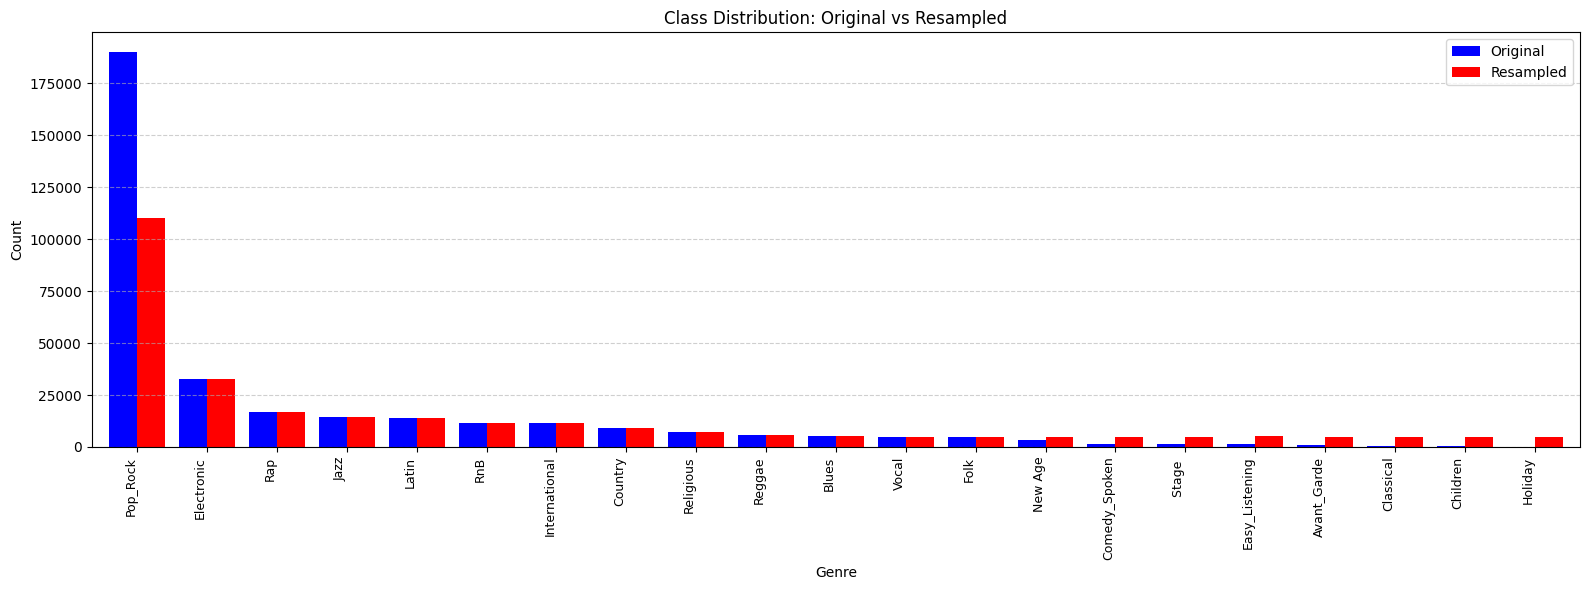

In [17]:

# Plot Original vs Resampled Distribution

# Original counts before resampling
orig_counts_df = (
    training1.groupBy("label")
    .count()
    .toPandas()
    .rename(columns={"count": "Original"})
    .set_index("label")
)

# Resampled counts
resampled_counts_df = (
    training_resampled.groupBy("label")
    .count()
    .toPandas()
    .rename(columns={"count": "Resampled"})
    .set_index("label")
)

# Combine into one DataFrame
combined_df = orig_counts_df.join(resampled_counts_df, how="outer").fillna(0).astype(int)
combined_df.sort_index(inplace=True)

# Use label-to-genre mapping from StringIndexer
genre_names = indexer_model.labels
combined_df.index = [genre_names[int(i)] if int(i) < len(genre_names) else f"Unknown_{int(i)}" for i in combined_df.index]

# Plot bar chart
ax = combined_df.plot(kind="bar", figsize=(16, 6), width=0.8, color=["blue", "red"])
plt.title("Class Distribution: Original vs Resampled")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90, ha="right", fontsize=9)
plt.legend(["Original", "Resampled"])
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("Images/class_distribution_original_vs_resampled_1.png")
plt.show()


In [79]:

# STEP 6: Train Multiclass Logistic Regression with multinomial option

from pyspark.ml.classification import LogisticRegression
import time

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=50,
    regParam=0.1,
    elasticNetParam=0.0,
    family="multinomial"
)

print("Training LogisticRegression (multinomial)...")
start_time = time.time()
model = lr.fit(training_resampled)
end_time = time.time()
print(f" Training completed in {end_time - start_time:.2f} seconds.")


Training LogisticRegression (multinomial)...


 Training completed in 27.62 seconds.


In [80]:

coefficients = model.coefficientMatrix  # rows = classes, columns = features

# Convert PySpark DenseMatrix to NumPy
coef_array = np.array(coefficients.toArray())

# Count how many columns (features) have at least one non-zero value
non_zero_features = np.sum(np.any(coef_array != 0, axis=0))
total_features = coef_array.shape[1]

print(f"Used features: {non_zero_features} out of {total_features}")


Used features: 111 out of 111


In [81]:

# STEP 7: Predict and evaluate on test set

pred = model.transform(test1).cache()

# Show metrics
metrics_lr = show_multiclass_metrics(pred, name="LogisticRegression (multinomial)")


Multiclass Metrics [LogisticRegression (multinomial)]

Accuracy:           0.6231
F1 Score:           0.5380
Weighted Precision: 0.5350
Weighted Recall:    0.6231



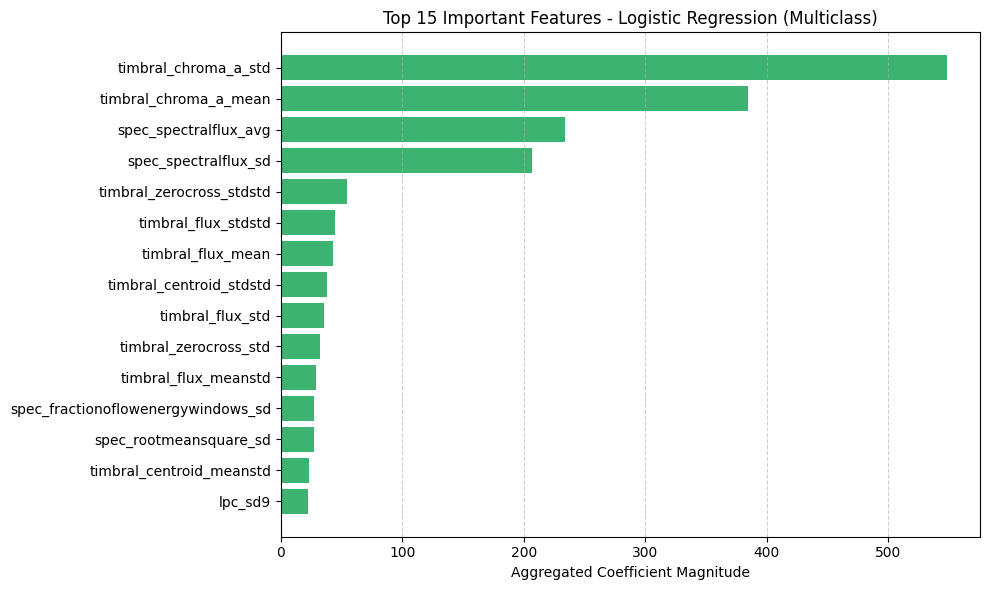

In [82]:


#  Get coefficients (num_classes x num_features)
coef_matrix = np.array(model.coefficientMatrix.toArray())  # shape: [21 x num_features]

#  Sum absolute values across classes to get global importance
feature_importance = np.sum(np.abs(coef_matrix), axis=0)

top_features = sorted(zip(feature_cols, feature_importance), key=lambda x: x[1], reverse=True)[:15]

#Create a DataFrame for plotting
df_top_features = pd.DataFrame(top_features, columns=["Feature", "Importance"])

#  Plot
plt.figure(figsize=(10, 6))
plt.barh(df_top_features["Feature"], df_top_features["Importance"], color="mediumseagreen")
plt.xlabel("Aggregated Coefficient Magnitude")
plt.title("Top 15 Important Features - Logistic Regression (Multiclass)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Images/logreg_top15_features.png")
plt.show()


In [83]:

# Create a Pandas DataFrame showing label-to-genre mapping
df_genres = pd.DataFrame({
    "label": list(range(len(labels))),
    "genre": labels
})

# Display the final table
display(df_genres)


,label,genre
0,0,Pop_Rock
1,1,Electronic
2,2,Rap
3,3,Jazz
4,4,Latin
5,5,RnB
6,6,International
7,7,Country
8,8,Religious
9,9,Reggae


In [93]:

from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

#  Get predictions as pandas
pdf = pred.select("label", "prediction").toPandas()

#  Classification report with precision, recall, support
report = classification_report(pdf["label"], pdf["prediction"], target_names=labels, output_dict=True)
df_genres = pd.DataFrame(report).transpose().iloc[:-3]  # drop avg rows

# Clean and reset index
df_genres = df_genres.reset_index().rename(columns={
    "index": "genre",
    "precision": "precision",
    "recall": "recall",
    "support": "support"
})

df_genres


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,genre,precision,recall,f1-score,support
0,Pop_Rock,0.658398,0.929285,0.770733,47529.0
1,Electronic,0.554093,0.450264,0.496812,8133.0
2,Rap,0.521899,0.612919,0.563758,4180.0
3,Jazz,0.425297,0.422785,0.424037,3555.0
4,Latin,0.398010,0.022851,0.043220,3501.0
5,RnB,0.277778,0.033182,0.059282,2863.0
6,International,0.260274,0.006692,0.013049,2839.0
7,Country,0.173077,0.003848,0.007528,2339.0
8,Religious,0.000000,0.000000,0.000000,1756.0
9,Reggae,0.200000,0.000722,0.001438,1386.0


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


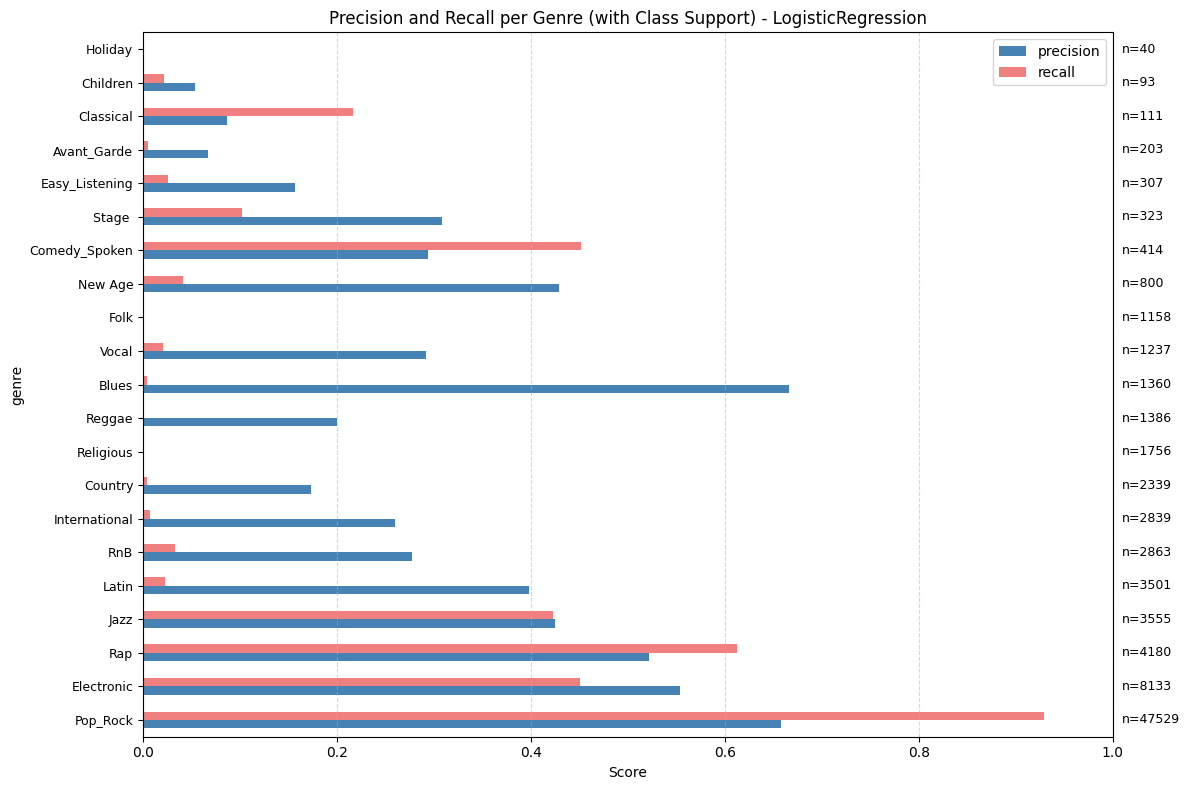

In [ ]:

#  Plot precision & recall
df_genres_plot = df_genres.set_index("genre")
ax = df_genres_plot[["precision", "recall"]].plot(
    kind="barh", figsize=(12, 8), color=["steelblue", "lightcoral"]
)

#  Add sample count labels
for i, (genre, row) in enumerate(df_genres_plot.iterrows()):
    ax.text(1.01, i, f"n={int(row['support'])}", va="center", fontsize=9)

#  Customize and save
plt.xlabel("Score")
plt.title("Precision and Recall per Genre (with Class Support) - LogisticRegression")
plt.xlim(0, 1)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Images/logreg_genre_precision_recall_with_support1.png")
plt.show()


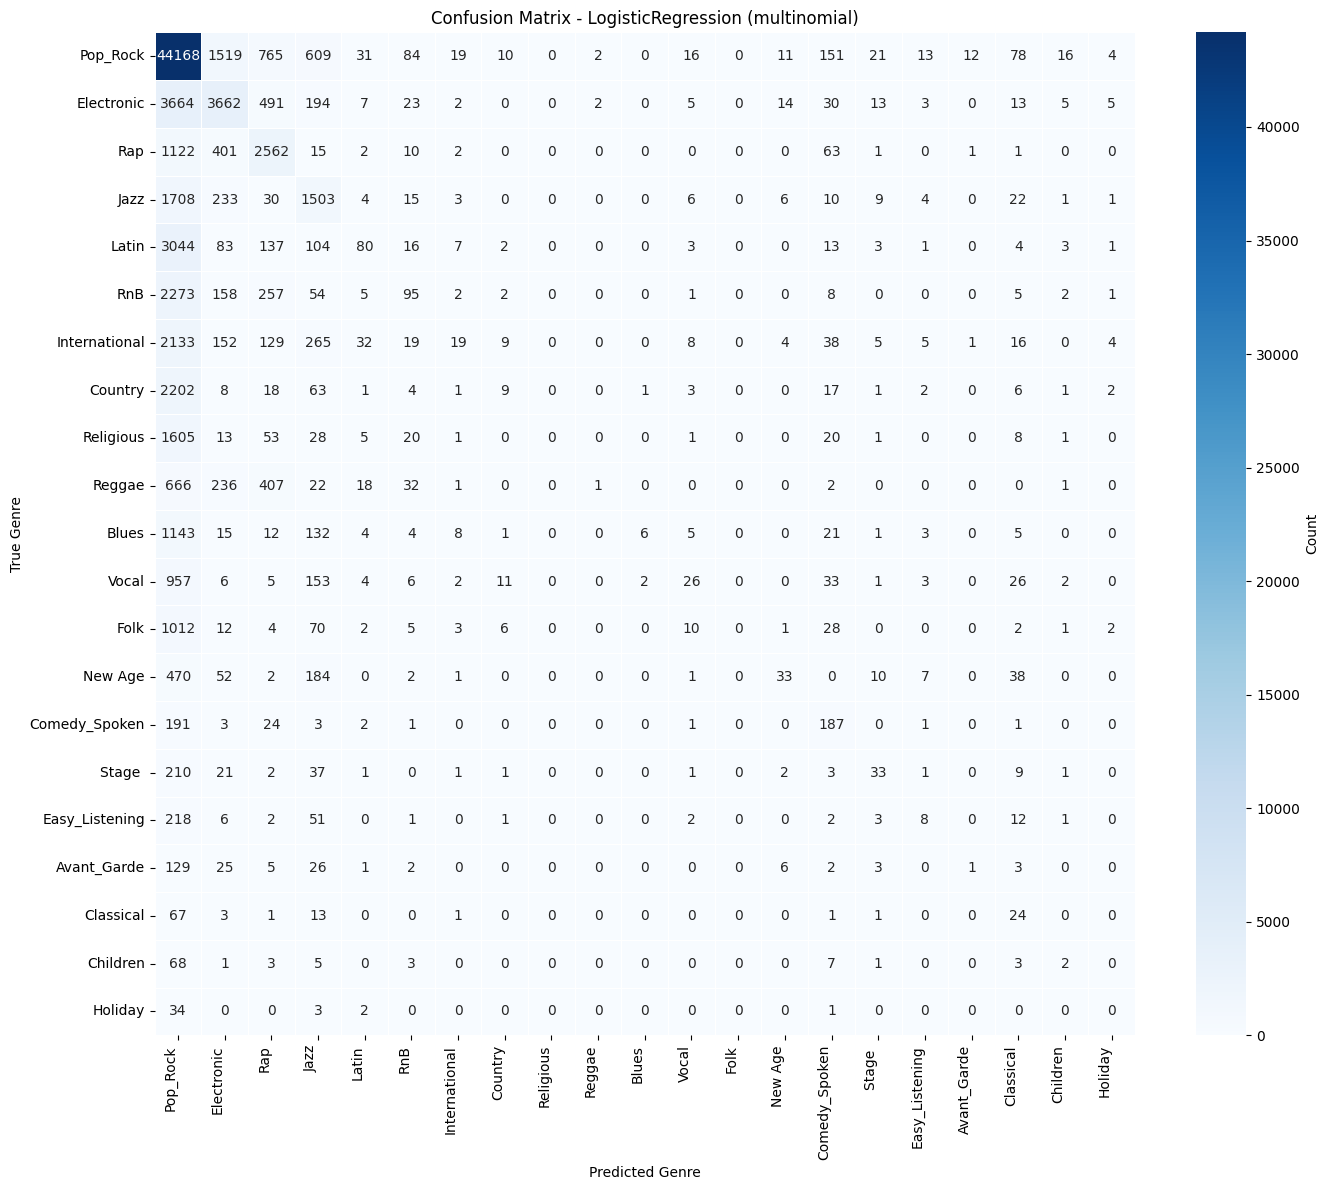

In [85]:

# STEP 9: Confusion matrix

conf_mat = confusion_matrix(pdf["label"], pdf["prediction"])
conf_df = pd.DataFrame(conf_mat, index=genre_names, columns=genre_names)

plt.figure(figsize=(14, 12))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues",
            xticklabels=genre_names, yticklabels=genre_names,
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix - LogisticRegression (multinomial)")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("Images/logreg_confusion_matrix1.png")
plt.show()


In [86]:

# STEP 10: Top 10 Misclassifications

misclassified = []
for i in range(len(genre_names)):
    for j in range(len(genre_names)):
        if i != j and conf_df.iloc[i, j] > 0:
            misclassified.append((genre_names[i], genre_names[j], conf_df.iloc[i, j]))

top_misclassified = sorted(misclassified, key=lambda x: -x[2])[:10]
top_df = pd.DataFrame(top_misclassified, columns=["True Genre", "Predicted Genre", "Count"])
print("Top 10 Most Misclassified Genre Pairs:")
display(top_df)


Top 10 Most Misclassified Genre Pairs:


,True Genre,Predicted Genre,Count
0,Electronic,Pop_Rock,3664
1,Latin,Pop_Rock,3044
2,RnB,Pop_Rock,2273
3,Country,Pop_Rock,2202
4,International,Pop_Rock,2133
5,Jazz,Pop_Rock,1708
6,Religious,Pop_Rock,1605
7,Pop_Rock,Electronic,1519
8,Blues,Pop_Rock,1143
9,Rap,Pop_Rock,1122


In [87]:

def get_misclassifications(genre_name, conf_df, genre_names):
    if genre_name not in genre_names:
        return pd.DataFrame()

    i = genre_names.index(genre_name)
    rows = []

    for j in range(len(genre_names)):
        if i != j and conf_df.iloc[i, j] > 0:
            rows.append((genre_name, genre_names[j], conf_df.iloc[i, j]))
        if i != j and conf_df.iloc[j, i] > 0:
            rows.append((genre_names[j], genre_name, conf_df.iloc[j, i]))

    return pd.DataFrame(rows, columns=["True Genre", "Predicted Genre", "Count"]).sort_values("Count", ascending=False)


In [88]:

get_misclassifications("Holiday", conf_df, genre_names)


,True Genre,Predicted Genre,Count
0,Holiday,Pop_Rock,34
2,Electronic,Holiday,5
1,Pop_Rock,Holiday,4
8,International,Holiday,4
3,Holiday,Jazz,3
5,Holiday,Latin,2
9,Country,Holiday,2
10,Folk,Holiday,2
4,Jazz,Holiday,1
6,Latin,Holiday,1


In [89]:

get_misclassifications("Children", conf_df, genre_names)


,True Genre,Predicted Genre,Count
0,Children,Pop_Rock,68
1,Pop_Rock,Children,16
15,Children,Comedy_Spoken,7
3,Electronic,Children,5
5,Children,Jazz,5
7,Latin,Children,3
8,Children,RnB,3
19,Children,Classical,3
4,Children,Rap,3
9,RnB,Children,2


In [90]:

get_misclassifications("Religious", conf_df, genre_names)


,True Genre,Predicted Genre,Count
0,Religious,Pop_Rock,1605
2,Religious,Rap,53
3,Religious,Jazz,28
5,Religious,RnB,20
8,Religious,Comedy_Spoken,20
1,Religious,Electronic,13
10,Religious,Classical,8
4,Religious,Latin,5
6,Religious,International,1
7,Religious,Vocal,1


In [91]:

get_misclassifications("Avant_Garde", conf_df, genre_names)


,True Genre,Predicted Genre,Count
0,Avant_Garde,Pop_Rock,129
5,Avant_Garde,Jazz,26
2,Avant_Garde,Electronic,25
1,Pop_Rock,Avant_Garde,12
9,Avant_Garde,New Age,6
3,Avant_Garde,Rap,5
11,Avant_Garde,Stage,3
12,Avant_Garde,Classical,3
7,Avant_Garde,RnB,2
10,Avant_Garde,Comedy_Spoken,2


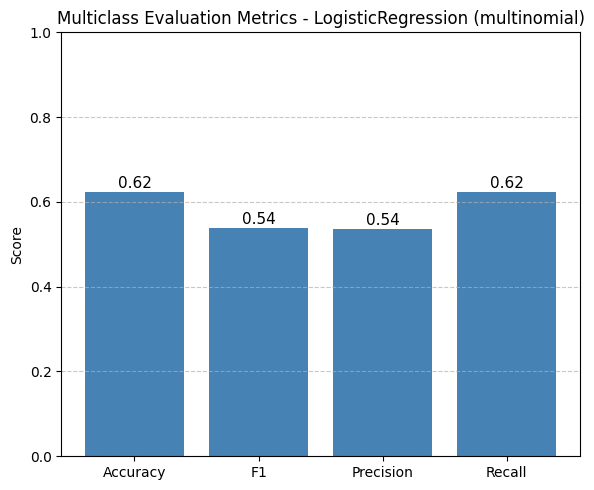

In [92]:

# STEP 11: Bar plot of overall metrics

metric_names = [k for k in metrics_lr if k != "Model"]
metric_values = [metrics_lr[k] for k in metric_names]

plt.figure(figsize=(6, 5))
bars = plt.bar(metric_names, metric_values, color="steelblue")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.01, f"{yval:.2f}", ha='center', fontsize=11)

plt.ylim(0, 1)
plt.title(f"Multiclass Evaluation Metrics - {metrics_lr['Model']}")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Images/logreg_evaluation_metrics1.png")
plt.show()


In [ ]:
# Run this cell before closing the notebook or kill your spark application by hand using the link in the Spark UI

stop_spark()
